## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
import sys
import logging

_handler = logging.StreamHandler(sys.stdout)
_handler.setFormatter(logging.Formatter('[%(levelname)s] %(name)s: %(message)s'))
_log = logging.getLogger('qsoabsfind')
_log.addHandler(_handler)
_log.setLevel(logging.INFO)
_log.propagate = False

In [2]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt


### Details of input file (SDSS DR1 Spectra)

In [3]:
# exploring ..data/sdss/qso_test_spectra.fits file
hdul = fits.open(f'../data/sdss/qso_test_spectra.fits')
header = hdul[0].header
hdul.close()
print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  SURVEY  = 'SDSS    '                                                            TARGET  = 'QSO     '                                                            DR      = '16      '                                                            AUTHOR  = 'Abhijeet Anand'                                                      END                                                                                                                                                                                                                                                                                                                                                                     

### Example output catalogs

I have already run `qsoabsfind` on `../data/sdss/qso_test_spectra.fits` and saved the resulting catalogs to:

- `../data/sdss/MgII_cat.fits`
- `../data/sdss/CIV_cat.fits`

The configuration used for this run is provided in `data/example_config.yaml`. All other constants are default values.

### Exploring output

[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Loaded 5 extensions from ../data/sdss/MgII_cat.fits
[INFO] qsoabsfind.datamodel:   ABSORBER: 21 rows
[INFO] qsoabsfind.datamodel:   METADATA: 21 rows
[INFO] qsoabsfind.datamodel:   COLUMN_DENSITY: 21 rows
[INFO] qsoabsfind.datamodel:   QSO_INFO: 100 rows
[INFO] qsoabsfind.datamodel: Time taken to read catalog from ../data/sdss/MgII_cat.fits: 0.05 seconds


Text(0.5, 0, 'MgII redshift')

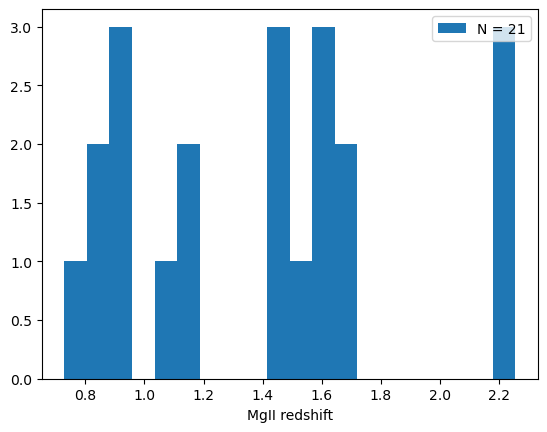

In [4]:
from qsoabsfind.datamodel import AbsorberData
mgii_tab = AbsorberData(f'../data/sdss/MgII_cat.fits', autoload=True)
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

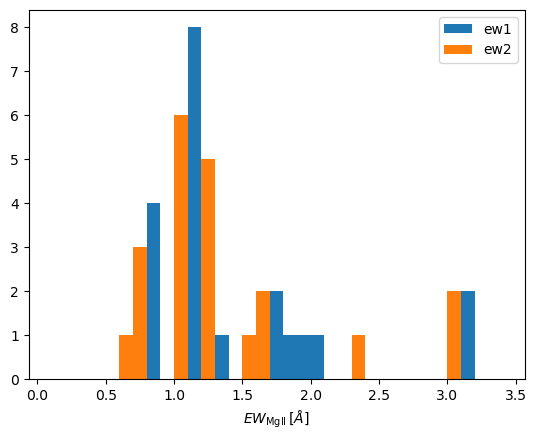

In [5]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 7...
[INFO] qsoabsfind.datamodel: Time taken to read ../data/sdss/qso_test_spectra.fits: 0.01 seconds
INFO: Zoomed y-limits for absorber MgII at z=1.570: ylo=0.327, yhi=1.220


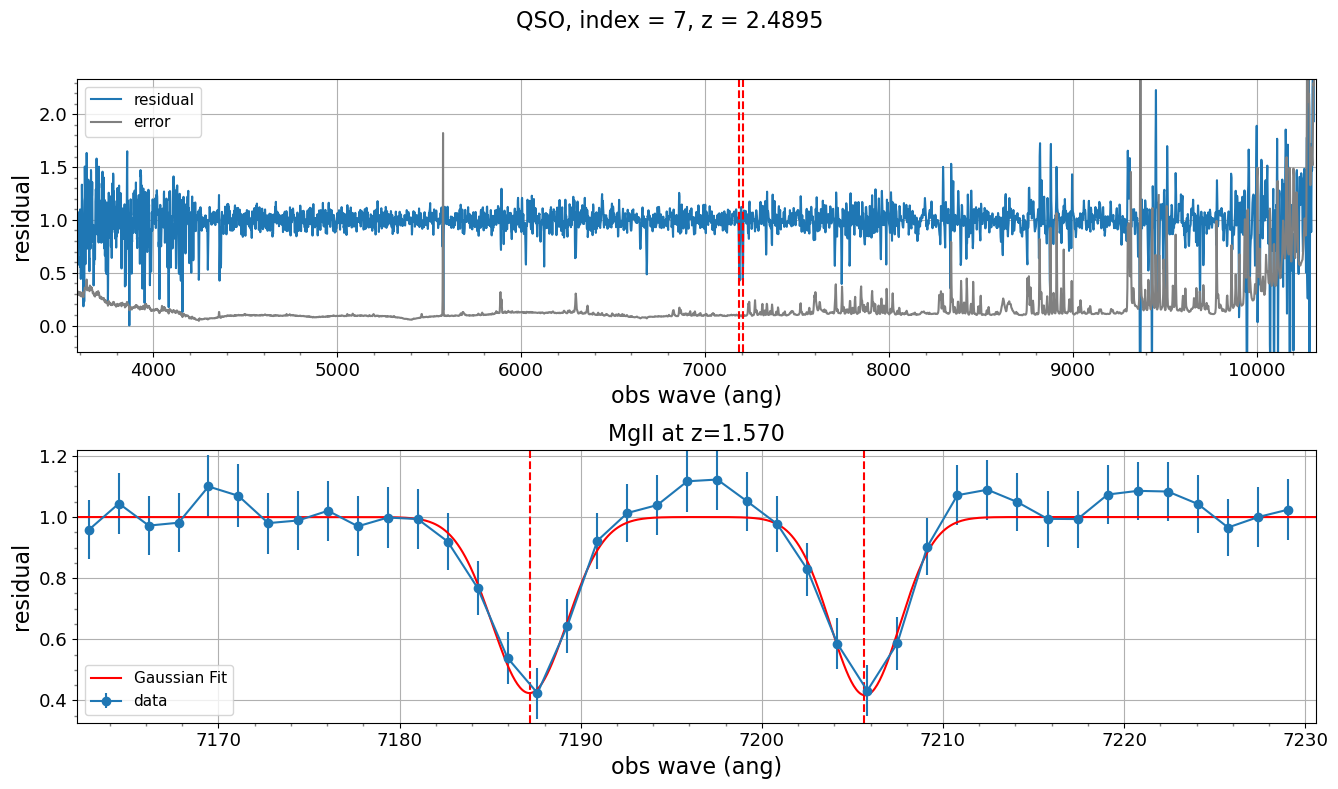

In [6]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead
import numpy as np

# select one from MgII_cat.fits
index = mgii_tab.catalog["INDEX_SPEC"].data[0]
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
kwargs = {'panel_color':'C0'}
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None, **kwargs)

2796.341030368898 2803.552354192036 0.7989466074621373 0.7431456430297833


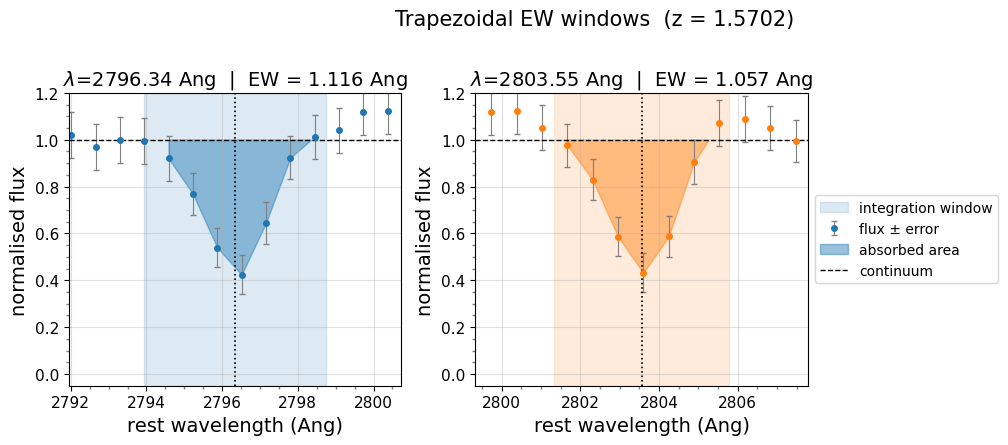

In [7]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z = zabs["Z_ABS"][0]
gauss_fit = zabs["GAUSS_FIT"][0]
line1, line2 = gauss_fit[1], gauss_fit[4]
sigma1, sigma2 = gauss_fit[2], gauss_fit[5]

print(line1, line2, sigma1, sigma2)


plot_trapezoidal_ew_windows(
    spectra.wavelength, spectra.flux, spectra.error, z=z,
    line1=line1, line2=line2,
    sigma1=sigma1, sigma2=sigma2,
    n_sigma=3,
)

### Using qsoabsfind internally as module

In [8]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants

parameters = load_constants(f'../data/sdss/sdss_constants.py')
read_single_spectrum_and_find_absorber(f'../data/sdss/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)

/Users/abhijeet/opt/anaconda3/envs/my_software/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:83: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:83: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/Users/abhijeet/opt/anaconda3/envs/my_software/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


{'index_spec': array([7]),
 'z_abs': array([1.57020398]),
 'gauss_fit': array([[5.75831376e-01, 2.79634106e+03, 7.98975159e-01, 5.83121258e-01,
         2.80355238e+03, 7.43156388e-01]]),
 'gauss_fit_std': array([[0.07004229, 0.1164241 , 0.11855919, 0.07155342, 0.10948889,
         0.11158128]]),
 'ew_1_mean': array([1.15323687]),
 'ew_2_mean': array([1.08624804]),
 'ew_total_mean': array([2.23948503]),
 'ew_1_error': array([0.14663747]),
 'ew_2_error': array([0.13972291]),
 'ew_total_error': array([0.20254639]),
 'z_abs_err': array([7.60038383e-05]),
 'sn_1': array([7.46148942]),
 'sn_2': array([6.83735866]),
 'vel_disp1': array([61.93449181]),
 'vel_disp2': array([53.15506774]),
 'vel_disp1_err': array([99.2046051]),
 'vel_disp2_err': array([0.42146647]),
 'delta_chi2_line1': array([17.57911679]),
 'delta_chi2_line2': array([17.83819562]),
 'pure_redchi2': array([100.28604126]),
 'snr_qso': 8.65913506505429}

[INFO] qsoabsfind.datamodel: Reading extension 'PRIMARY' (PrimaryHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'ABSORBER' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'METADATA' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'QSO_INFO' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Reading extension 'COLUMN_DENSITY' (BinTableHDU)
[INFO] qsoabsfind.datamodel: Loaded 5 extensions from ../data/sdss/CIV_cat.fits
[INFO] qsoabsfind.datamodel:   ABSORBER: 13 rows
[INFO] qsoabsfind.datamodel:   METADATA: 13 rows
[INFO] qsoabsfind.datamodel:   COLUMN_DENSITY: 13 rows
[INFO] qsoabsfind.datamodel:   QSO_INFO: 100 rows
[INFO] qsoabsfind.datamodel: Time taken to read catalog from ../data/sdss/CIV_cat.fits: 0.05 seconds


Text(0.5, 0, 'CIV redshift')

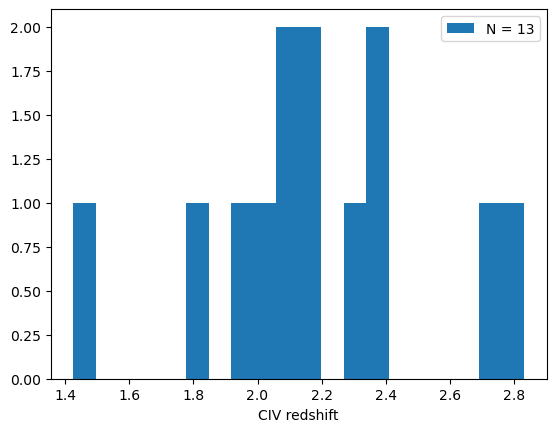

In [9]:
civ_tab = AbsorberData(f'../data/sdss/CIV_cat.fits', autoload=True)
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

[INFO] qsoabsfind.datamodel: Time taken to read ../data/sdss/qso_test_spectra.fits: 0.04 seconds
INFO: plotting CIV for QSO INDEX = 55...
INFO: Zoomed y-limits for absorber CIV at z=2.031: ylo=0.540, yhi=1.232


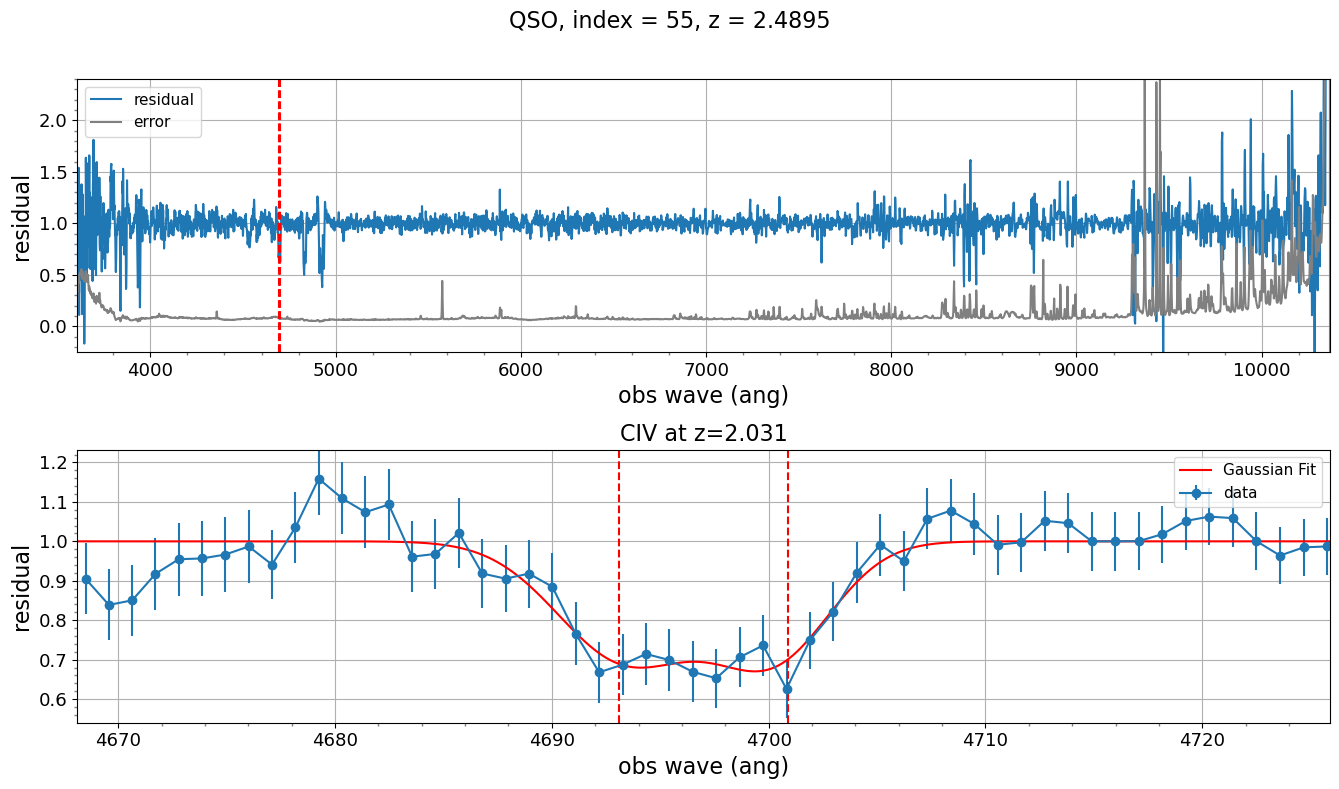

In [10]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead

# select a random spectra from MgII_cat.fits
index1 = civ_tab.catalog["INDEX_SPEC"].data[4]
spectra1 = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index1, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index1}...')
# select corresponding zabs table
zabs1 = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index1]
kwargs = {'panel_color':'C0'}
plot_absorber(spectra1, 'CIV', zabs1, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index1}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None, **kwargs)

1548.3260138667436 1550.5452827186364 1.0550451042375442 0.8833169741997333


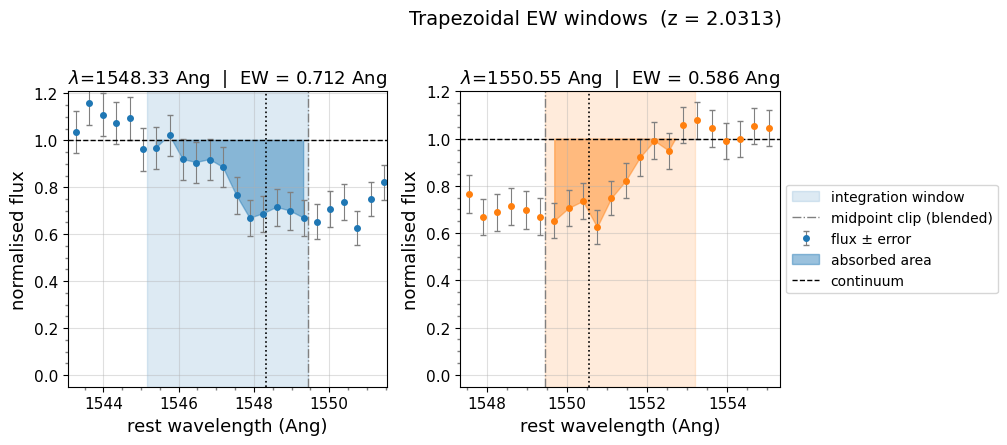

In [11]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z1 = zabs1["Z_ABS"][0]
gauss_fit1 = zabs1["GAUSS_FIT"][0]
line1_1, line2_1 = gauss_fit1[1], gauss_fit1[4]
sigma1_1, sigma2_1 = gauss_fit1[2], gauss_fit1[5]

print(line1_1, line2_1, sigma1_1, sigma2_1)

kwargs={'fontsize':14}
plot_trapezoidal_ew_windows(
    spectra1.wavelength, spectra1.flux, spectra1.error, z=z1,
    line1=line1_1, line2=line2_1,
    sigma1=sigma1_1, sigma2=sigma2_1,
    n_sigma=3,**kwargs
)